# Electronics vs. Economy-Wide Manufacturing Volatility

## The Question

Is Division 26's month-to-month volatility unusual for Malaysia's manufacturing sector, or is this just how manufacturing behaves overall?

Notebook 01 found that Division 26 (electronics manufacturing output) shows continuous month-to-month volatility across 2021–2026, with no isolable dip attributable specifically to the semiconductor shortage. This notebook tests whether that volatility is unique to electronics, or a structural feature of Malaysia's manufacturing sector as a whole; using the national headline Industrial Production Index as a baseline comparison.

## The Answer

Division 26's month-to-month volatility is not unique to electronics; it closely mirrors Malaysia's national headline manufacturing index across the entire 2021–2026 window. Both series show the same seasonal dips (clustering early each calendar year, consistent with widely-documented Chinese New Year production slowdowns across Malaysian industry generally) and the same overall upward trajectory. This is a structural feature of Malaysian manufacturing broadly, not an electronics-specific pattern.

This finding strengthens, rather than overturns, notebook 01's conclusion. If the whole manufacturing sector exhibits this same sawtooth behavior, it further supports that Division 26's swings were never a meaningful shortage signature; they are simply what Malaysian manufacturing output looks like in any given year, shortage or not. The absence of an isolable shortage effect in notebook 01 is not a limitation of the data; it reflects that electronics manufacturing's volatility is business-as-usual for the sector it belongs to.

## Loading Division 26 and the national headline index for comparison

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ipi_2d = pd.read_csv('../data/raw/ipi_2d.csv')
ipi_headline = pd.read_csv('../data/raw/ipi.csv')

div26 = ipi_2d[
    (ipi_2d['series'] == 'abs') &
    (ipi_2d['division'] == 26) &
    (ipi_2d['date'] >= '2021-01-01') &
    (ipi_2d['date'] <= '2026-06-01')
].copy()
div26['date'] = pd.to_datetime(div26['date'])

headline = ipi_headline[
    (ipi_headline['series'] == 'abs') &
    (ipi_headline['date'] >= '2021-01-01') &
    (ipi_headline['date'] <= '2026-06-01')
].copy()
headline['date'] = pd.to_datetime(headline['date'])

print(div26.shape, headline.shape)

(65, 4) (65, 4)


In [2]:
# House chart style v2: MBB-style chart conventions:
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, exhibit style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Comparing volatility: Division 26 vs. the national headline index

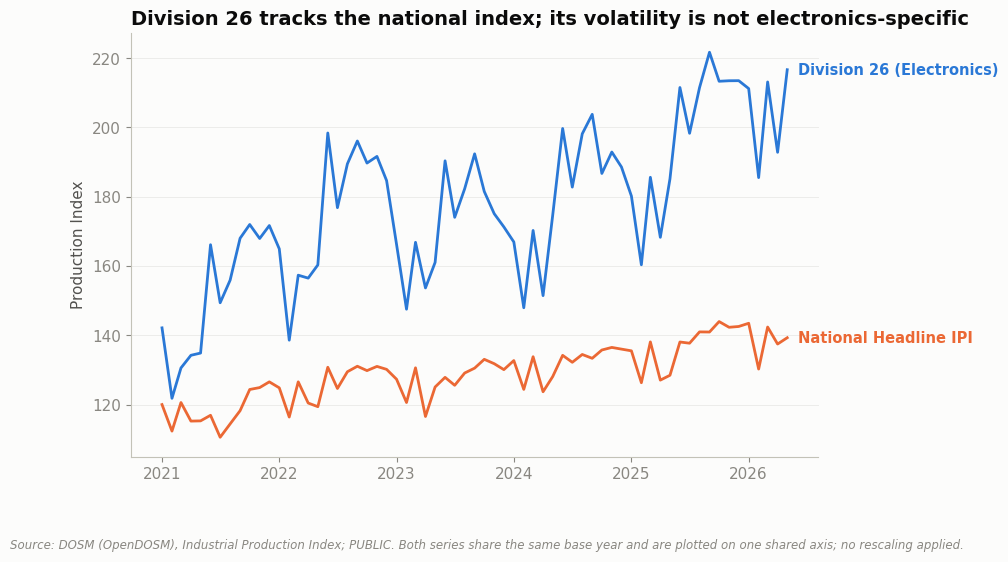

In [3]:
fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.plot(div26['date'], div26['index'], linewidth=2, color=ACCENT_1)
ax.plot(headline['date'], headline['index'], linewidth=2, color=ACCENT_2)

end_label(ax, div26['date'].iloc[-1], div26['index'].iloc[-1], 'Division 26 (Electronics)', ACCENT_1, weight='bold')
end_label(ax, headline['date'].iloc[-1], headline['index'].iloc[-1], 'National Headline IPI', ACCENT_2, weight='bold')

ax.set_title('Division 26 tracks the national index; its volatility is not electronics-specific', loc='left')
ax.set_ylabel('Production Index')
ax.set_xlabel('')
fig.subplots_adjust(right=0.78)

add_source(ax.figure, 'Source: DOSM (OpenDOSM), Industrial Production Index; PUBLIC. Both series share the '
                       'same base year and are plotted on one shared axis; no rescaling applied.')
plt.show()


## Strategic Recommendation

- **Businesses evaluating Malaysia's electronics manufacturing sector should expect regular seasonal volatility as the norm**, not a red flag, the swings observed are consistent with economy-wide manufacturing patterns, not sector-specific instability.
- **This shared seasonality (likely tied to Chinese New Year production slowdowns) should be factored into supply chain planning and inventory timing** for any business sourcing from Malaysian manufacturers, regardless of sector.
- **Cross-referencing a sector-specific dataset against an economy-wide baseline is a valuable diagnostic step before concluding an event caused a disruption**; this notebook's core contribution is methodological as much as substantive: a dip that looks meaningful in isolation may simply be normal noise once compared against the right baseline.

## Confidence & Caveats

- **The seasonal pattern (dips clustering early each year) is observed, not formally tested.** This notebook did not statistically decompose the series into trend/seasonal/residual components, the seasonal claim is a visual read of the chart, not a rigorous seasonal-adjustment analysis.
- **The national headline index is broader in scope than "all manufacturing"** (it includes mining and electricity too), which is a real, if modest, scope mismatch when using it as Division 26's baseline.
- **Co-movement between two series does not rule out a real electronics-specific effect entirely**; it's possible a genuine shortage effect exists but is small relative to the shared seasonal swings, making it invisible at this resolution. This notebook can rule out a *large, isolable* effect, not a *subtle* one.